# DINO erase & re-run (baseline vs A/B/C)

Single-frame variant of `03_dinov3_detect.ipynb` that tries to surface *weaker*
dolphins (e.g. submerged ones) that lose against the dominant heatmap peak:
`detect -> erase/suppress what was found -> detect again`.

Two mechanisms can help:

1. `compute_anomaly_heatmap` builds its reference pool from the frame's own
   tokens, so a big/strong object contaminates the "water" reference and
   flattens the contrast of the rest.
2. The mask thresholds are relative percentiles (99.5 seed / 98 growth): with a
   dominant peak the next peak does not make the top 0.5%; once it is gone it
   becomes the new top.

Honest limit: the loop does **not** invent signal. A submerged dolphin whose
contrast does not beat the water texture will not appear no matter how many
iterations. Also `run_zoom_detector` already re-runs DINO on nested zooms, so
part of the improvement may already exist -- hence the baseline.

Four variants over the same frame:

- **Baseline** -- `run_zoom_detector` with no suppression (iteration 0 of every loop).
- **B -- erase (inpaint / patch) + re-forward** -- delete the found pixels with a
  SAM3-box mask (DINO bbox fallback) and re-run the full detector.
- **A -- suppress score** -- pixels untouched: the found regions leave the
  reference pool and the percentile, and are re-segmented.
- **C -- suppress tokens** -- like A, but the tokens of the found patches are
  replaced by the mean of the survivors (never zeros: `extract_patch_tokens`
  L2-normalizes and a zero vector scores as maximum anomaly).

`leaked_detections` (candidates inside already erased regions) is the key
diagnostic: they are erase artifacts (inpaint hole, pasted-texture seam), not
animals.

In [1]:
%matplotlib inline
import gc
import json
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from fish_segmentation.dinov3 import (
    load_backbone,
    plot_erase_records,
    run_dino_erase_loop,
    run_dino_suppress_loop,
)
from fish_segmentation.paths import find_repo_root, load_env
from fish_segmentation.sam3_utils import detection_erase_mask
from fish_segmentation.video_io import load_frame_rgb

load_env()
ROOT = find_repo_root()

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    # SAM3's image-model ViT MLP (sam3.perflib.fused.addmm_act) hardcodes bf16
    # activations against fp32 weights, so the image model only runs under bf16
    # autocast (same as 05_smoke_test.ipynb); DINOv3 tolerates it too.
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

VIDEO_PATH = ROOT / "dataset" / "processed" / "20260813_213529_7f994a2f" / "video.mp4"
if not VIDEO_PATH.exists():
    VIDEO_PATH = ROOT / "data" / "test_media" / "dolphin_00.mp4"

FRAME_INDEX = 0              # exact frame index to iterate on
DINO_LONG_SIDE = 1024
DINO_RESOLUTION_SCALE = 4.0  # tuned on the 4K originals
ZONE_MERGE_GAP = 0.08
MIN_ZONE_FRACTION = 0.25
MIN_CONFIRMATIONS = 2
MAX_ITERATIONS = 2           # baseline + one rerun (raise to 3 to see saturation)
ERASE_DILATE_PX = 12         # >= 1 ViT patch at the detector's scale
MIN_SCORE = 0.5
MIN_SOLIDITY = 0.25
SAM3_MAX_AREA_FRACTION = 0.25  # a box prompt on open water can segment the whole crop
SAM3_MIN_SCORE = 0.5

OUTPUTS = ROOT / "notebooks" / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
print(f"video: {VIDEO_PATH}")
print(f"device: {device}")

video: /workspace/fish-segmentation/dataset/processed/20260813_213529_7f994a2f/video.mp4
device: cuda


## 1. Frame and DINO backbone

The loop works on ONE frame at native resolution (`load_frame_rgb`, exact
index). The erase mask can be built from SAM3 box prompts, so the SAM3 image
model is built here too; without it `run_dino_erase_loop` falls back to the DINO
detection boxes.

In [2]:
frame_np = load_frame_rgb(str(VIDEO_PATH), FRAME_INDEX)
assert frame_np is not None, f"frame {FRAME_INDEX} not readable in {VIDEO_PATH}"
frame = Image.fromarray(frame_np)
print(f"frame {FRAME_INDEX}: {frame.size}")

model, processor = load_backbone("facebook/dinov3-vitl16-pretrain-lvd1689m", device=device)

frame 0: (3840, 2160)


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

## 2. SAM3 image model for the erase masks

`segment_boxes` runs one box prompt per detection and keeps the best mask;
`detection_erase_mask` accepts it when the score is high enough and the area is
below `max_area_fraction` of the frame, otherwise it falls back to the DINO
bbox/radius (a class-agnostic box on open water often segments the whole crop).
The mask feeds the erase modes only -- the suppression modes never touch pixels.

In [3]:
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.model_builder import build_sam3_image_model

sam3_model = build_sam3_image_model(device=device)
sam3_processor = Sam3Processor(sam3_model, device=device)

mask_fn = partial(
    detection_erase_mask,
    processor=sam3_processor,
    max_area_fraction=SAM3_MAX_AREA_FRACTION,
    min_score=SAM3_MIN_SCORE,
)

/workspace/fish-segmentation/sam3_src/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/workspace/fish-segmentation/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 3. Baseline + B: erase & re-run

Iteration 0 is the baseline (`run_zoom_detector` untouched). From iteration 1 on
the image has the found regions erased -- `inpaint` fills them with the
surrounding water (may leave a smooth hole), `patch` pastes a nearby water
patch. The mask is dilated by `ERASE_DILATE_PX` so no mixed patches are left at
the object border.

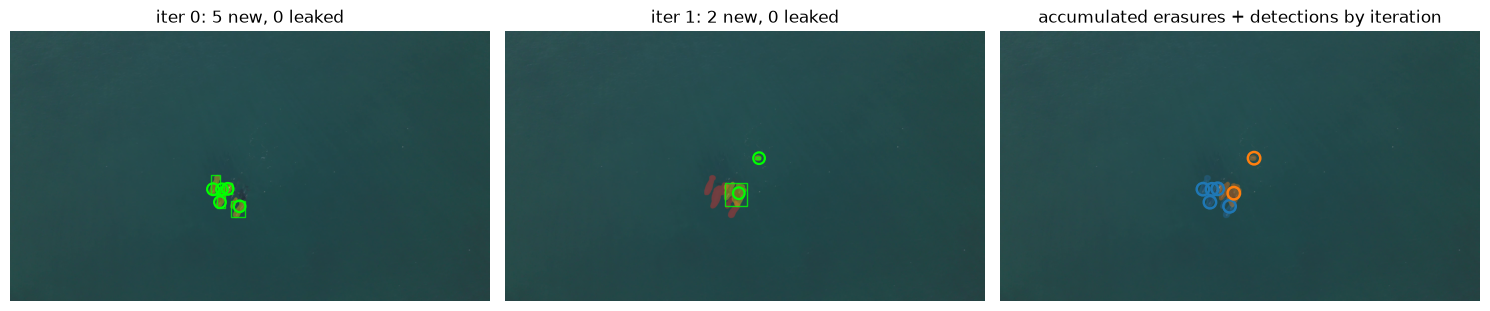

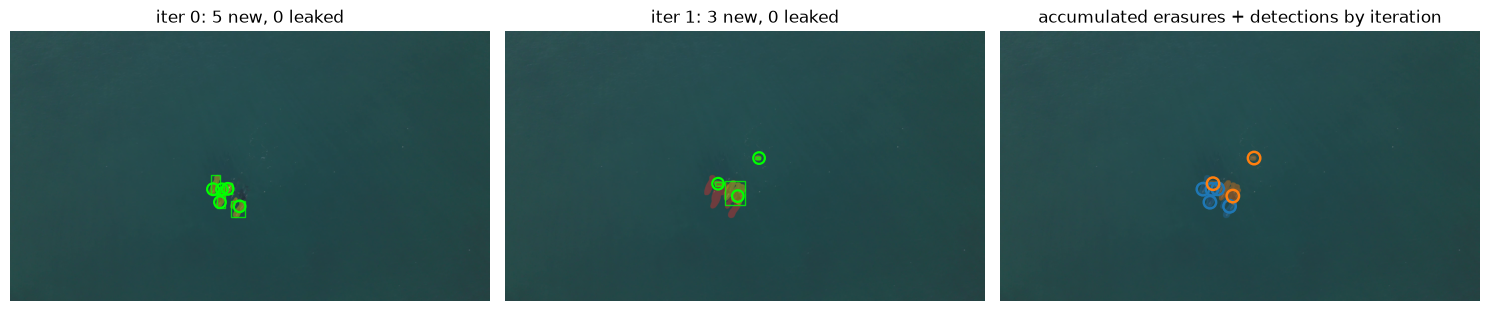

In [4]:
loop_kwargs = dict(
    max_iterations=MAX_ITERATIONS,
    dilate_px=ERASE_DILATE_PX,
    min_score=MIN_SCORE,
    min_solidity=MIN_SOLIDITY,
    long_side=DINO_LONG_SIDE,
    resolution_scale=DINO_RESOLUTION_SCALE,
    merge_gap=ZONE_MERGE_GAP,
    min_zone_fraction=MIN_ZONE_FRACTION,
    min_confirmations=MIN_CONFIRMATIONS,
    device=device,
)

inpaint_records = run_dino_erase_loop(
    frame, model, processor, erase_mode="inpaint", mask_fn=mask_fn, **loop_kwargs
)
plot_erase_records(frame, inpaint_records)

patch_records = run_dino_erase_loop(
    frame, model, processor, erase_mode="patch", mask_fn=mask_fn, **loop_kwargs
)
plot_erase_records(frame, patch_records)

## 4. A/C: score and token suppression

No pixels are touched: `run_dino_suppress_loop` feeds the accumulated mask to
every view. `"score"` removes the found patches from the reference pool and pins
their score; `"tokens"` also replaces their tokens with the mean of the
survivors before scoring (one forward pass, cheaper than the erase + re-forward).

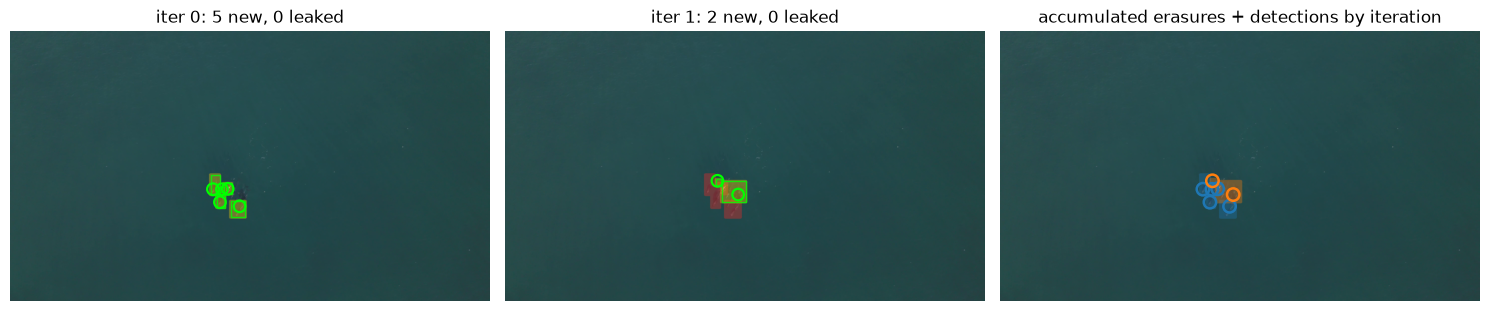

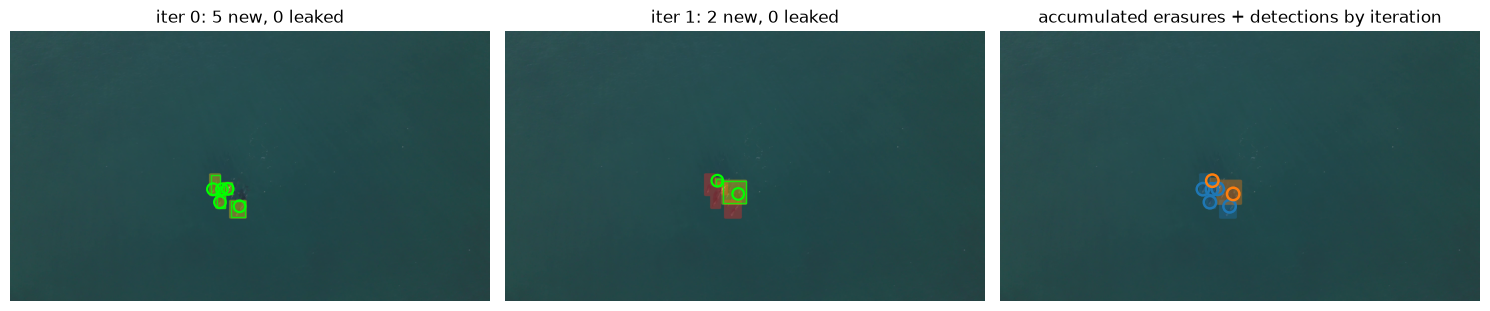

In [5]:
score_records = run_dino_suppress_loop(
    frame, model, processor, suppress_mode="score", **loop_kwargs
)
plot_erase_records(frame, score_records)

token_records = run_dino_suppress_loop(
    frame, model, processor, suppress_mode="tokens", **loop_kwargs
)
plot_erase_records(frame, token_records)

## 5. A/B comparison and summary JSON

Per mode: candidates per iteration, leaked detections (erase artifacts) and the
mean score of the new candidates. Iteration 0 is the shared baseline. The JSON
stores detection metadata only (no pixels) in `notebooks/outputs/` (gitignored).

In [6]:
runs = {
    "erase_inpaint": inpaint_records,
    "erase_patch": patch_records,
    "suppress_score": score_records,
    "suppress_tokens": token_records,
}

summary = {
    "video": str(VIDEO_PATH.relative_to(ROOT)),
    "frame_index": FRAME_INDEX,
    "settings": {
        "long_side": DINO_LONG_SIDE,
        "resolution_scale": DINO_RESOLUTION_SCALE,
        "merge_gap": ZONE_MERGE_GAP,
        "min_zone_fraction": MIN_ZONE_FRACTION,
        "min_confirmations": MIN_CONFIRMATIONS,
        "max_iterations": MAX_ITERATIONS,
        "erase_dilate_px": ERASE_DILATE_PX,
        "min_score": MIN_SCORE,
        "min_solidity": MIN_SOLIDITY,
        "sam3_max_area_fraction": SAM3_MAX_AREA_FRACTION,
        "sam3_min_score": SAM3_MIN_SCORE,
    },
    "modes": {
        name: [
            {
                "iteration": record["iteration"],
                "n_detections": len(record["detections"]),
                "n_new": len(record["new_detections"]),
                "n_leaked": len(record["leaked_detections"]),
                "mean_score_new": (
                    float(np.mean([det["score_mean"] for det in record["new_detections"]]))
                    if record["new_detections"]
                    else 0.0
                ),
                "new_detections": [
                    {
                        "x": round(float(det["x"]), 4),
                        "y": round(float(det["y"]), 4),
                        "level": det["level"],
                        "score_mean": round(float(det["score_mean"]), 4),
                        "solidity": round(float(det["solidity"]), 4),
                        "area": int(det["area"]),
                    }
                    for det in record["new_detections"]
                ],
                "leaked_detections": [
                    {
                        "x": round(float(det["x"]), 4),
                        "y": round(float(det["y"]), 4),
                        "score_mean": round(float(det["score_mean"]), 4),
                    }
                    for det in record["leaked_detections"]
                ],
            }
            for record in records
        ]
        for name, records in runs.items()
    },
}

summary_path = (
    OUTPUTS
    / f"dino_erase_rerun_{VIDEO_PATH.parent.name}_{VIDEO_PATH.stem}_frame{FRAME_INDEX}.json"
)
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(summary_path)

print("\nbaseline (iteration 0 of every loop):")
print(
    f"  {len(inpaint_records[0]['new_detections'])} new, "
    f"{len(inpaint_records[0]['leaked_detections'])} leaked"
)
for name, iterations in summary["modes"].items():
    line = " | ".join(
        f"it{it['iteration']}: {it['n_new']} new, {it['n_leaked']} leaked, "
        f"mean score {it['mean_score_new']:.3f}"
        for it in iterations
    )
    print(f"{name:16s} {line}")

/workspace/fish-segmentation/notebooks/outputs/dino_erase_rerun_20260813_213529_7f994a2f_video_frame0.json

baseline (iteration 0 of every loop):
  5 new, 0 leaked
erase_inpaint    it0: 5 new, 0 leaked, mean score 0.742 | it1: 2 new, 0 leaked, mean score 0.590
erase_patch      it0: 5 new, 0 leaked, mean score 0.742 | it1: 3 new, 0 leaked, mean score 0.739
suppress_score   it0: 5 new, 0 leaked, mean score 0.742 | it1: 2 new, 0 leaked, mean score 0.705
suppress_tokens  it0: 5 new, 0 leaked, mean score 0.742 | it1: 2 new, 0 leaked, mean score 0.765


## 6. Visual validation crops

Each panel is the image the detector saw at that iteration (previous erase
already applied), cropped around the erased region, so the inpaint hole / patch
seam can be checked by eye against the `leaked` count. For the suppression modes
the image is always the original frame, so the crop shows the object the
detector was told to ignore.

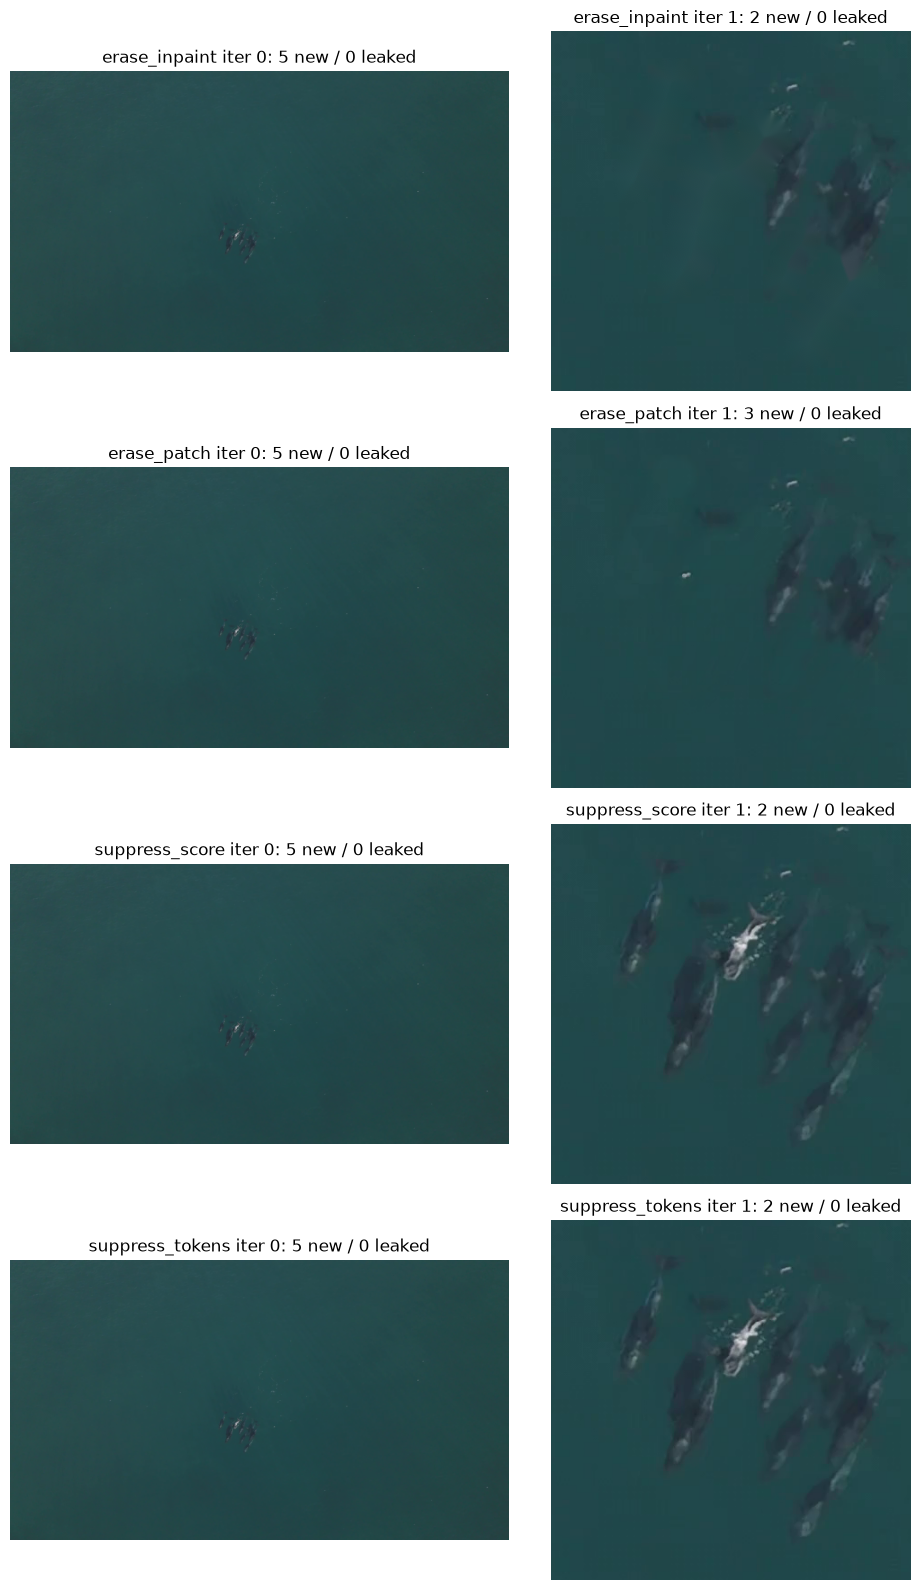

In [7]:
CROP_RADIUS = 200  # px around the erased-region centroid in the original frame

fig, axes = plt.subplots(
    len(runs), MAX_ITERATIONS, figsize=(5 * MAX_ITERATIONS, 4 * len(runs)), squeeze=False
)
for row, (name, records) in enumerate(runs.items()):
    for col, record in enumerate(records):
        ax = axes[row, col]
        panel = np.asarray(record["image"].convert("RGB"))
        mask = record["suppressed_mask"]
        if mask.any():
            ys, xs = np.nonzero(mask)
            cx, cy = int(xs.mean()), int(ys.mean())
            x0, y0 = max(0, cx - CROP_RADIUS), max(0, cy - CROP_RADIUS)
            x1, y1 = min(frame.width, cx + CROP_RADIUS), min(frame.height, cy + CROP_RADIUS)
            panel = panel[y0:y1, x0:x1]
        ax.imshow(panel)
        ax.set_title(
            f"{name} iter {record['iteration']}: "
            f"{len(record['new_detections'])} new / {len(record['leaked_detections'])} leaked"
        )
        ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Cleanup

The loops hold no session; just free the models and the CUDA cache.

In [8]:
del model, processor, sam3_model, sam3_processor
gc.collect()
torch.cuda.empty_cache()
print(f"peak VRAM: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

peak VRAM: 7.49 GB
